# Importación y descarga de datos

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Descarga de datos

tickers = {
    "EURUSD": "EURUSD=X",
    "GBPUSD": "GBPUSD=X",
    "USDJPY": "JPY=X",
    "BTC": "BTC-USD",
    "ETH": "ETH-USD"
}

data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start="2018-01-01",end="2026-03-31", progress=False)
    df = df[["Close"]].rename(columns={"Close": name})
    data[name] = df
    print(f"{name}: {len(df)} registros descargados")

EURUSD: 2145 registros descargados
GBPUSD: 2145 registros descargados
USDJPY: 2145 registros descargados
BTC: 3011 registros descargados
ETH: 3011 registros descargados


Vemos diferencias de registros, pero eso viene porque el mercado tradicional opera de lunes a viernes, en cambio,  el mercado de las criptomonedas opera los 365 días del año.

# Primera exploración

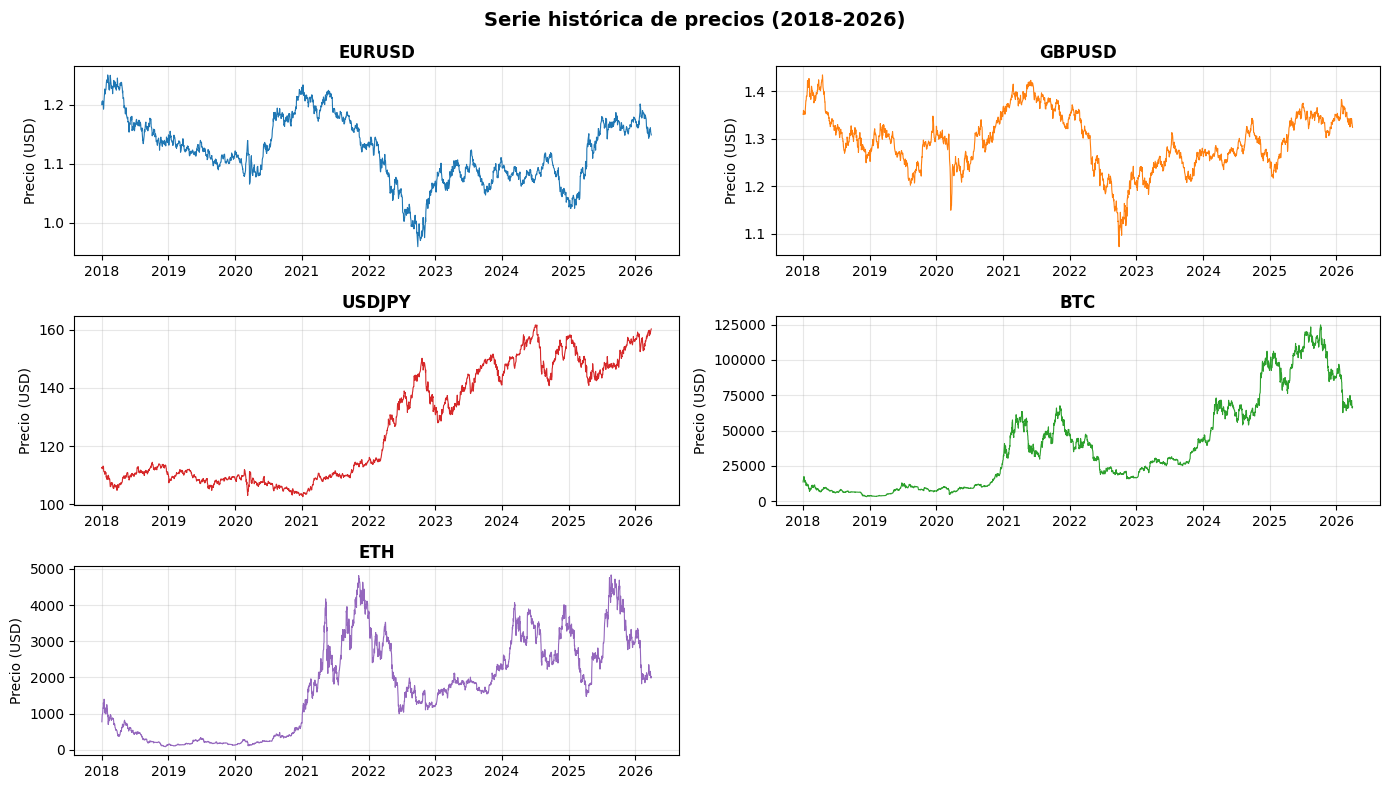

Gráfico guardado en la carpeta results


In [2]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
fig.suptitle("Serie histórica de precios (2018-2026)", fontsize=14, fontweight="bold")

colores = {"EURUSD": "#1f77b4", "GBPUSD": "#ff7f0e", "USDJPY": "#d62728", "BTC": "#2ca02c", "ETH": "#9467bd"}

for ax, (name,df) in zip (axes.flatten(), data.items()):
    ax.plot(df.index, df[name], color=colores[name], linewidth=0.8)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Precio (USD)")
    ax.grid (True, alpha=0.3)

axes[2, 1].set_visible(False)
plt.tight_layout()
plt.savefig("../results/01_series_historicas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en la carpeta results")

## Análisis de series históricas de precios (2018-2026)

**Forex:** EUR/USD y GBP/USD oscilan en rangos acotados sin tendencia estructural, es un comportamiento consistente con la hipótesis de mercado eficiente. USD/JPY es el par más interesante - estable entre 105-115 hasta 2021, se deprecia bruscamente hasta 150-160 yenes a partir de 2022 por el diferencial de tipos entre la Reserva Federal Americana y el Banco de Japón, introduciendo una no-linealidad relevante para los modelos. En el Q1 2026 el yen sigue presionado cerca de los 158-160. Una posible explicación serían las tensiones en Oriente Medio que encarecen la energía y penalizan a Japón como gran importador de petróleo, aunque este trabajo no analiza causas macroeconómicas. El EUR/USD cotiza en torno a 1.15-1.16 en marzo 2026, con el dólar como activo refugio ante la incertidumbre geopolítica global.

**Criptomonedas:** BTC y ETH muestran tendencia alcista de largo plazo con ciclos de explosión y corrección del 70-80%. BTC alcanzó ~120.000$ en 2025 antes de corregir a ~65.000$ en 2026. ETH replica el patrón con mayor volatilidad relativa, cayendo por debajo de 2.000$ a principios de 2026. 

**Conclusión:** La diferencia estructural entre Forex y Cripto justifica analizarlos por separado y motiva el uso de modelos progresivamente más complejos. La corrección de cripto en el Q1 2026 ilustra además la sensibilidad de estos activos a factores exógenos como el conflicto en Oriente Medio, que ningún modelo puramente técnico puede anticipar. 

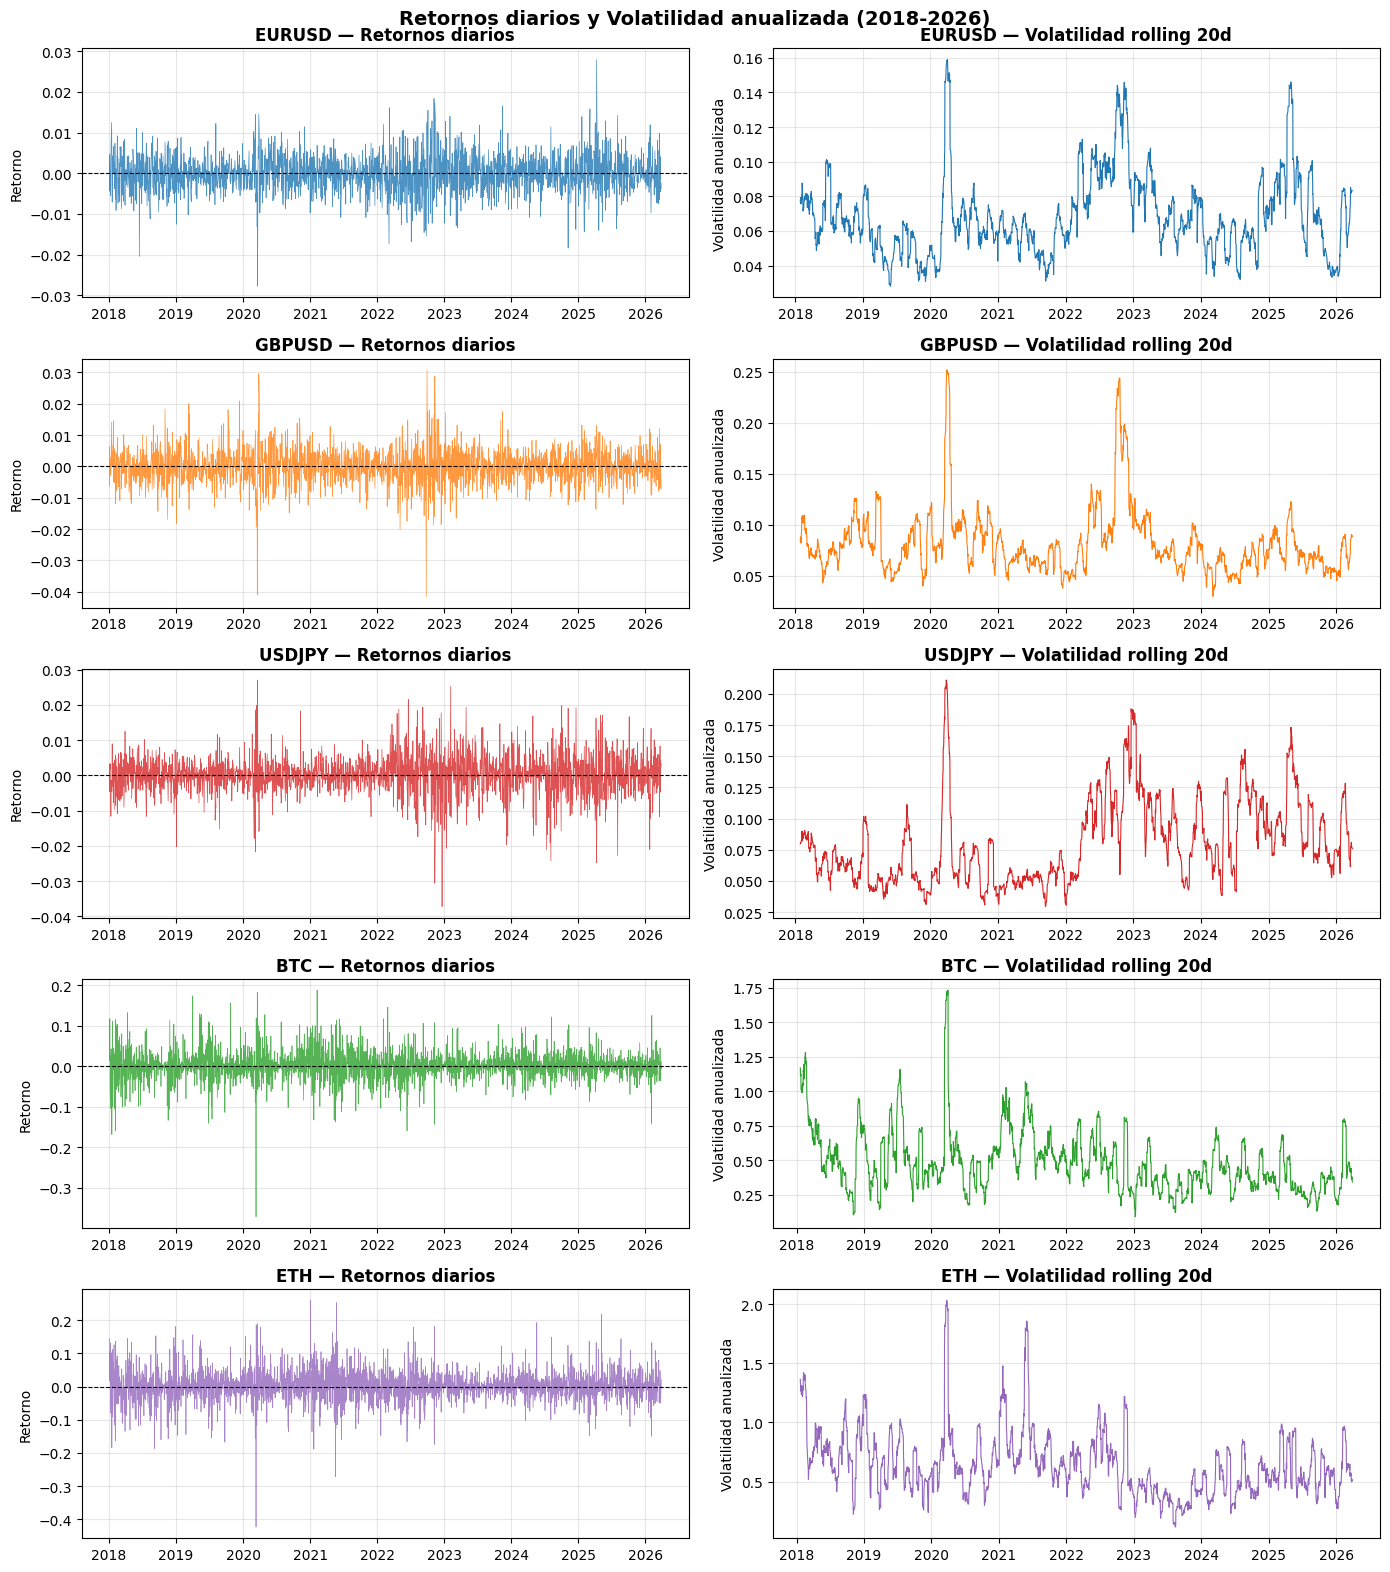

Gráfico guardado en la carpeta results


In [3]:
# Calcular retornos logarítmicos y volatilidad rolling
retornos = {}
volatilidad = {}

for name, df in data.items():
    # Retornos logarítmicos diarios
    ret = df[name].pct_change().dropna()
    retornos[name] = ret
    
    # Volatilidad rolling de 20 días (media móvil de la desviación estándar)
    vol = ret.rolling(window=20).std() * (252 ** 0.5) # Anualizada
    volatilidad[name] = vol
    
# Visualizar retornos y volatilidad
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
fig.suptitle("Retornos diarios y Volatilidad anualizada (2018-2026)", fontsize=14, fontweight="bold")

for i, name in enumerate(data.keys()):
    color = colores[name]
    
    # Retornos
    axes[i, 0].plot(retornos[name].index, retornos[name], color=color, linewidth=0.5, alpha=0.8)
    axes[i, 0].set_title(f"{name} — Retornos diarios", fontweight="bold")
    axes[i, 0].set_ylabel("Retorno")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    
    # Volatilidad
    axes[i, 1].plot(volatilidad[name].index, volatilidad[name], color=color, linewidth=0.8)
    axes[i, 1].set_title(f"{name} — Volatilidad rolling 20d", fontweight="bold")
    axes[i, 1].set_ylabel("Volatilidad anualizada")
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/02_retornos_volatilidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en la carpeta results")

## Retornos diarios y volatilidad anualizada (2018-2026)
- **Forex:** Retornos acotados en un rango de ±3% diario. Volatilidad anualizada base del 5-15%, con picos puntuales durante el COVID-19 (2020) y la crisis energética (2022-2023). Reflejan mercados maduros y estables.

- **USD/JPY:** Muestra tres regímenes de volatilidad claros: estabilidad inicial (2018-2021), repunte severo hasta el 20% (2022-2023) impulsado por la divergencia monetaria entre la Reserva Federal Americana(Fed) y el Banco de Japón(BoJ), y una moderación posterior (8-12%).

- **Cripto:** Magnitud de retornos extrema (hasta 30-40% en una sola sesión) y picos de volatilidad de entre el 150-200%. El nivel base o "suelo" de volatilidad estructural de BTC se sitúa en el 25-30% anualizado, superando con creces los máximos históricos de las divisas tradicionales.

# Limpieza y almacenamiento

In [4]:
import os

# Guarda cada serie en CSV
os.makedirs("../data", exist_ok=True)

for name, df in data.items():
    filepath = f"../data/{name.lower()}_raw.csv"
    df.to_csv(filepath)
    print(f"Guardado: {filepath}")
    
print("\nTodos los datos guardados correctamente en la carpeta data")

Guardado: ../data/eurusd_raw.csv
Guardado: ../data/gbpusd_raw.csv
Guardado: ../data/usdjpy_raw.csv
Guardado: ../data/btc_raw.csv
Guardado: ../data/eth_raw.csv

Todos los datos guardados correctamente en la carpeta data


# Detector de regímenes de volatilidad


In [5]:
regimenes = {}

for name in data.keys():
    vol = volatilidad[name].squeeze().dropna()
    
    # Umbral: percentil 70 de la volatilidad histórica de cada activo
    umbral = vol.quantile(0.70)
    
    # Etiquetar régimen
    regimen = (vol > umbral).map({True: "Alta", False: "Baja"})    # True = alta volatilidad, False = baja volatilidad
    regimenes[name] = regimen
    
    pct_alta = (regimen == "Alta").mean() * 100
    print(f"Resultados umbrales con su volatilidad anualizada\n")
    
    print (f"{name}: umbral={umbral:.4f} | Alta vol: {pct_alta:.2f}% del tiempo")

Resultados umbrales con su volatilidad anualizada

EURUSD: umbral=0.0759 | Alta vol: 30.02% del tiempo
Resultados umbrales con su volatilidad anualizada

GBPUSD: umbral=0.0875 | Alta vol: 30.02% del tiempo
Resultados umbrales con su volatilidad anualizada

USDJPY: umbral=0.0942 | Alta vol: 30.02% del tiempo
Resultados umbrales con su volatilidad anualizada

BTC: umbral=0.5476 | Alta vol: 29.99% del tiempo
Resultados umbrales con su volatilidad anualizada

ETH: umbral=0.7350 | Alta vol: 29.99% del tiempo


- **Brecha de magnitud:** Las gráficas evidencian la extrema divergencia entre mercados; el umbral que define el régimen de alta volatilidad en Bitcoin es 7 veces superior al del EUR/USD.

- **Elección del Percentil 70:** Fijar el corte en este nivel garantiza aislar exactamente el 30% de las sesiones más turbulentas. Esta decisión se alinea con los estándares habituales de la literatura académica (donde es común utilizar rangos entre el 70% y el 75%).

- **Objetivo e homogeneización:** El uso de un percentil relativo, en lugar de un valor de volatilidad absoluto, actúa como factor de equilibrio. Es la herramienta que permite normalizar los datos y hacer una comparación justa entre activos con dinámicas de movimiento tan dispares.


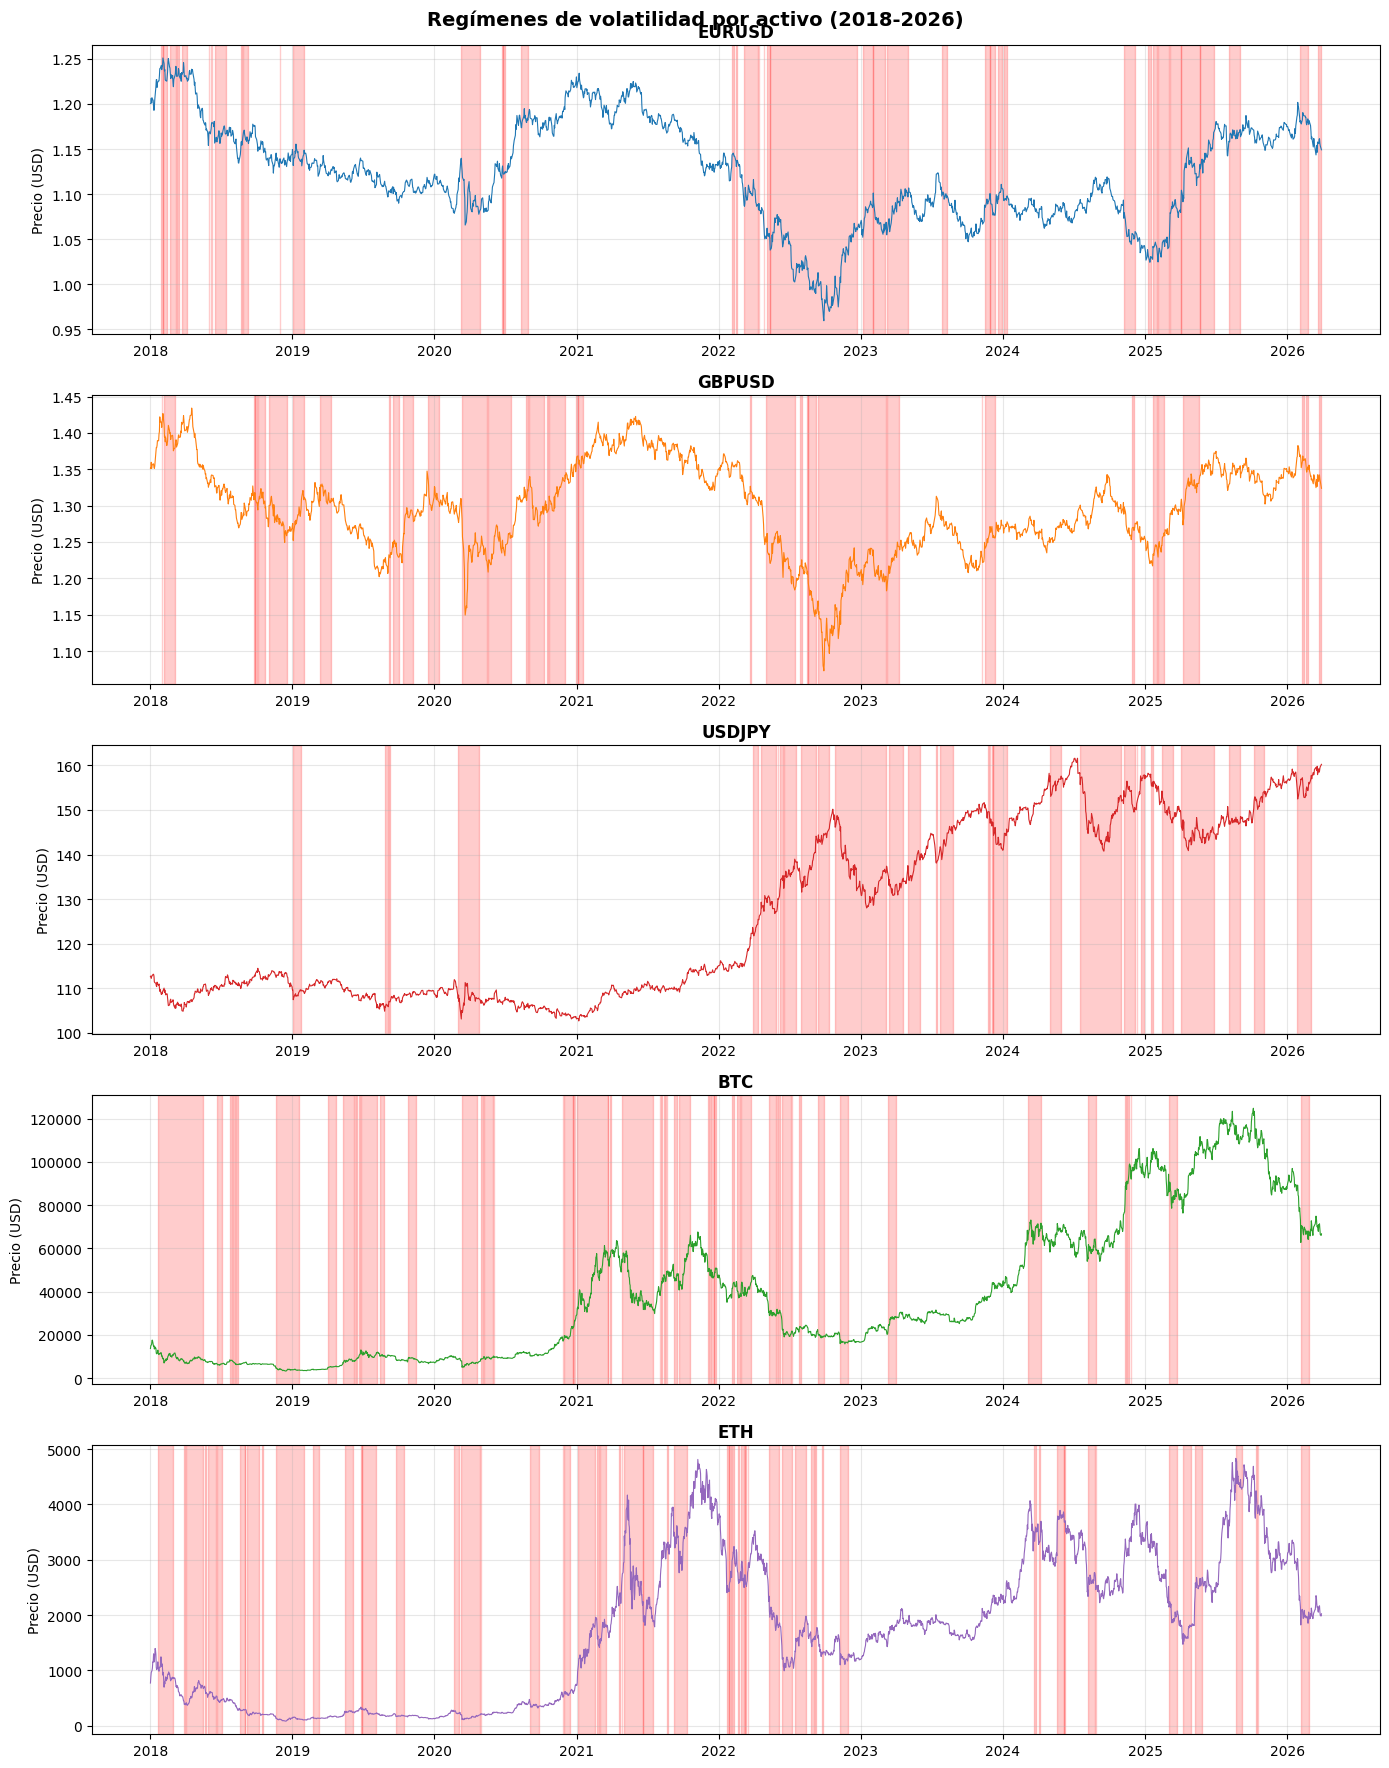

Gráfico guardado en la carpeta resultados


In [6]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18))
fig.suptitle("Regímenes de volatilidad por activo (2018-2026)", fontsize=14, fontweight="bold")

for i, name in enumerate(data.keys()):
    precio = data[name][name]
    regimen = regimenes[name]
    color = colores[name]
    
    axes[i].plot(precio.index, precio, color=color, linewidth=0.8, zorder=2)
    axes[i].set_title(f"{name}", fontweight="bold")
    axes[i].set_ylabel("Precio (USD)")
    axes[i].grid(True, alpha=0.3)
    
    # Resaltar las zonas de alta volatilidad en rojo
    in_regime = False
    start = None
    for date, val in regimen.items():
        if val == "Alta" and not in_regime:
            start = date
            in_regime = True
        elif val == "Baja" and in_regime:
            axes[i].axvspan(start, date, alpha=0.2, color="red", zorder=1)
            in_regime = False
    if in_regime:
        axes[i].axvspan(start, regimen.index[-1], alpha=0.2, color="red", zorder=1)

plt.tight_layout()
plt.savefig("../results/03_regimenes_volatilidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en la carpeta resultados")

## Análisis de regímenes de volatilidad (Zonas Rojas)
- **Forex (EUR/USD, GBP/USD):** Presentan zonas de alta volatilidad breves y localizadas. Los shocks (COVID-19/Brexit en 2020 y crisis energética en 2022) son absorbidos con rapidez, devolviendo al activo a su régimen estable. Esto evidencia la alta resiliencia y madurez de estas divisas frente a perturbaciones externas.

- **USD/JPY:** Ruptura de régimen evidente a partir de 2022. La divergencia de políticas monetarias entre la Fed y el BOJ desplaza al par a un estado de volatilidad persistente que se prolonga hasta 2026, alimentado por la inestabilidad geopolítica actual.

- **Criptomonedas (BTC, ETH):** La volatilidad es un factor estructural y no meramente coyuntural. Las zonas rojas son frecuentes, extensas y recurrentes, manifestándose tanto en ciclos de crecimiento explosivo como en periodos de corrección severa.

# Estadísticas descriptivas por régimen

In [7]:
# Estadísticas descriptivas por régimen de volatilidad
resultados = []

for name in data.keys():
    ret = retornos[name].squeeze()
    reg = regimenes[name].squeeze()
    
    # Alinear índices
    idx_comun = ret.index.intersection(reg.index)
    ret = ret[idx_comun]
    reg = reg[idx_comun]
    
    for regimen_val, regimen_nombre in [("Baja", "Baja volatilidad"), ("Alta", "Alta volatilidad")]:
        mask = reg == regimen_val
        ret_reg = ret[mask]
        
        resultados.append({
            "Activo": name,
            "Régimen": regimen_nombre,
            "Días": len(ret_reg),
            "Retorno medio diario (%)": round(ret_reg.mean() * 100, 4),
            "Desv. estándar (%)": round(ret_reg.std() * 100, 4),
            "Retorno máximo (%)": round(ret_reg.max() * 100, 4),
            "Retorno mínimo (%)": round(ret_reg.min() * 100, 4),
        })

df_stats = pd.DataFrame(resultados)
print(df_stats.to_string(index=False))

# Guardar en CSV
df_stats.to_csv("../results/estadisticas_regimenes.csv", index=False)
print("\nTabla guardada en la carpeta results")

Activo          Régimen  Días  Retorno medio diario (%)  Desv. estándar (%)  Retorno máximo (%)  Retorno mínimo (%)
EURUSD Baja volatilidad  1487                   -0.0097              0.3684              1.2222             -1.3797
EURUSD Alta volatilidad   638                    0.0141              0.6042              2.7919             -2.7752
GBPUSD Baja volatilidad  1487                   -0.0072              0.4297              2.0846             -1.4999
GBPUSD Alta volatilidad   638                    0.0114              0.7544              3.0772             -4.1440
USDJPY Baja volatilidad  1487                    0.0249              0.4094              1.8246             -2.1076
USDJPY Alta volatilidad   638                    0.0064              0.7840              2.7049             -3.7250
   BTC Baja volatilidad  2094                    0.0982              2.4589             12.9478            -11.3960
   BTC Alta volatilidad   897                    0.1428              4.8

## Análisis estadístico por regímenes

- **Forex:** La desviación estándar se duplica al pasar al régimen de alta volatilidad. Los movimientos extremos (colas de la distribución) se amplian, pero permanecen estrictamente acotados (la caída máxima registrada es del -4.14% en GBP/USD).

- **Criptomonedas:** La brecha entre regímenes es extrema. En alta volatilidad, las caídas máximas intradía alcanzan el -37% (BTC)y el -42% (ETH), un orden de magnitud (x10) superior al del mercado de divisas.

- **Naturaleza de la volatilidad:** En cripto, los retornos medios son positivos en ambos escenarios e incluso superiores en alta volatilidad. Esto evidencia que los picos de varianza recogen tanto bull markets explosivos como crashes severos. En Forex, la alta volatilidad representa puramente turbulencia direccionalmente neutral. 

In [8]:
# Guardar regímenes etiquetados en CSV

for name in data.keys():
    df_export = pd.DataFrame({
        "Close": data[name][name].squeeze(),
        "Retorno": retornos[name].squeeze(),
        "Volatilidad_20d": volatilidad[name].squeeze(),
        "Regimen": regimenes[name].squeeze()
    })
    
    filepath = f"../data/{name.lower()}_processed.csv"
    df_export.to_csv(filepath)
    print(f"Guardado: {filepath}")

print("\nPipeline completo. Datos listos para modelado.")

Guardado: ../data/eurusd_processed.csv
Guardado: ../data/gbpusd_processed.csv
Guardado: ../data/usdjpy_processed.csv
Guardado: ../data/btc_processed.csv
Guardado: ../data/eth_processed.csv

Pipeline completo. Datos listos para modelado.


Los archivos continenen lo siguiente: 

+ **Close:** precio de cierre

+ **Retorno:** retorno diario calculado con pct_change

+ **Volatilidad_20d:** volatilidad rolling anualizado de 20 días

+ **Regimen:** etiquetado "Alta" (alta volatilidad) o "Baja" (baja volatilidad)